# 🌊 NB7 — GDACS Tsunami Alert API
**Source:** `https://www.gdacs.org/gdacsapi/api/events/geteventlist/SEARCH`  
**Protocol:** HTTP GET  
**Schedule:** Every 15 minutes (conditional on M≥6.0, depth<150km, coastal region)  
**Auth:** None

Queries active Red and Orange global tsunami alerts from the Global Disaster Alert and Coordination System (GDACS), operated by the European Commission and the United Nations. Filters results to alerts within 2000 km of the epicentre.


Swagger UI: https://www.gdacs.org/gdacsapi/swagger/index.html

In [2]:
! pip install requests pandas matplotlib --quiet


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
import datetime
import urllib.parse

HEADERS = {"User-Agent": "EQMonitor/1.0"}

LAT, LON = -17.7134, 178.0650
MAG, DEPTH = 5.2, 226.8
MAX_DIST_KM = 2000

TSUNAMI_MIN_MAG   = 6.0
TSUNAMI_MAX_DEPTH = 150.0
PACIFIC_RIM = {"FIJI","TONGA","VANUATU","SOLOMON","SAMOA","PACIFIC",
               "JAPAN","CHILE","INDONESIA","ALASKA","NEW ZEALAND","PHILIPPINES"}

def haversine_km(la1, lo1, la2, lo2) -> float:
    R=6371; la1,lo1,la2,lo2=map(math.radians,[la1,lo1,la2,lo2])
    a=math.sin((la2-la1)/2)**2+math.cos(la1)*math.cos(la2)*math.sin((lo2-lo1)/2)**2
    return round(2*R*math.asin(math.sqrt(max(0,a))),1)

print("✅ Config ready")

✅ Config ready


## Pre-Check Gate

GDACS is only queried when the event meets the tsunami risk thresholds. This avoids unnecessary API calls for deep or small events.

In [4]:
region = "FIJI REGION"
reasons = []
if MAG   < TSUNAMI_MIN_MAG:   reasons.append(f"M{MAG} < M{TSUNAMI_MIN_MAG} threshold")
if DEPTH > TSUNAMI_MAX_DEPTH: reasons.append(f"Depth {DEPTH}km > {TSUNAMI_MAX_DEPTH}km")
if not any(r in region.upper() for r in PACIFIC_RIM): reasons.append("Not coastal")

QUERY_OK = len(reasons) == 0
print(f"Pre-check: {'✅ QUERY' if QUERY_OK else '⏭️  SKIP'}")
for r in reasons: print(f"  → {r}")
if not QUERY_OK:
    print("\n⚠️  Pre-check failed — GDACS would be skipped for this event.")
    print("   Continuing anyway to demonstrate the API access.")

Pre-check: ⏭️  SKIP
  → M5.2 < M6.0 threshold
  → Depth 226.8km > 150.0km

⚠️  Pre-check failed — GDACS would be skipped for this event.
   Continuing anyway to demonstrate the API access.


## Fetch GDACS Alerts

In [5]:
params = urllib.parse.urlencode([
    ("eventtype", "TS"),
    ("alertlevel", "Red"),
    ("alertlevel", "Orange"),
    ("limit", 20),
])
URL = f"https://www.gdacs.org/gdacsapi/api/events/geteventlist/SEARCH?{params}"
print(f"Querying GDACS: {URL}")

r = requests.get(URL, timeout=15, headers=HEADERS)
r.raise_for_status()
data = r.json()
print(f"✅ Response: HTTP {r.status_code} | Total alerts: {len(data.get('features', []))}")
data

Querying GDACS: https://www.gdacs.org/gdacsapi/api/events/geteventlist/SEARCH?eventtype=TS&alertlevel=Red&alertlevel=Orange&limit=20
✅ Response: HTTP 200 | Total alerts: 19


{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'bbox': [156.1, 28.7, 156.1, 28.7],
   'geometry': {'type': 'Point', 'coordinates': [156.1, 28.7]},
   'properties': {'eventtype': 'TC',
    'eventid': 1001270,
    'episodeid': 44,
    'eventname': 'SINLAKU-26',
    'glide': 'TC-2026-000050-FSM',
    'name': 'Tropical Cyclone SINLAKU-26',
    'description': 'Tropical Cyclone SINLAKU-26',
    'htmldescription': 'Red Tropical Cyclone SINLAKU-26 in Northern Mariana Islands, Guam from: 09 Apr 2026  to: 19 Apr 2026 .',
    'icon': 'https://www.gdacs.org/images/gdacs_icons/maps/Green/TC.png',
    'iconoverall': 'https://www.gdacs.org/images/gdacs_icons/maps/Red/TC.png',
    'url': {'geometry': 'https://www.gdacs.org/gdacsapi/api/polygons/getgeometry?eventtype=TC&eventid=1001270&episodeid=44',
     'report': 'https://www.gdacs.org/report.aspx?eventid=1001270&episodeid=44&eventtype=TC',
     'details': 'https://www.gdacs.org/gdacsapi/api/events/geteventdata?eventtype=TC&eventi

## Parse + Filter by Distance

In [5]:
rows = []
for feat in data.get("features", []):
    p      = feat.get("properties", {})
    coords = feat.get("geometry", {}).get("coordinates", [None, None])
    a_lat  = p.get("coordinates", {}).get("lat") or (coords[1] if len(coords)>1 else None)
    a_lon  = p.get("coordinates", {}).get("lon") or (coords[0] if len(coords)>0 else None)
    dist   = haversine_km(LAT, LON, a_lat, a_lon) if a_lat and a_lon else None
    sev    = p.get("severity", {})
    rows.append({
        "event_id":    p.get("eventid"),
        "name":        p.get("eventname", "?"),
        "alert_level": p.get("alertlevel", "?"),
        "alert_score": p.get("alertscore"),
        "country":     p.get("country", "?"),
        "wave_height_m": sev.get("value"),
        "wave_unit":   sev.get("unitname"),
        "is_current":  p.get("iscurrent", False),
        "from_date":   p.get("fromdate"),
        "dist_km":     dist,
        "url":         p.get("url", {}).get("report", ""),
    })

df_all    = pd.DataFrame(rows) if rows else pd.DataFrame()
df_nearby = df_all[df_all["dist_km"] <= MAX_DIST_KM] if not df_all.empty else df_all

print(f"Total alerts:  {len(df_all)}")
print(f"Within {MAX_DIST_KM}km: {len(df_nearby)}")
if not df_nearby.empty:
    display(df_nearby[['name','alert_level','wave_height_m','country','is_current','dist_km','url']])
else:
    print("\n✅ No active tsunami alerts near the epicentre.")

Total alerts:  19
Within 2000km: 0

✅ No active tsunami alerts near the epicentre.


## Verdict

In [6]:
active = df_nearby[df_nearby['is_current']==True] if not df_nearby.empty else pd.DataFrame()

SEVERITY_RANK = {"Red":4,"Orange":3,"Green":2}

if not active.empty:
    top = active.loc[active['alert_level'].map(lambda x: SEVERITY_RANK.get(x,0)).idxmax()]
    verdict = f"⚠️  OFFICIAL TSUNAMI ALERT: [{top['alert_level']}] {top['name']}"
    action  = "🚨 Follow official evacuation orders immediately!"
else:
    # Rule-based fallback
    is_pac = any(r in region.upper() for r in PACIFIC_RIM)
    rl = ("HIGH"     if MAG>=7.5 and DEPTH<70  and is_pac else
          "MODERATE" if MAG>=6.5 and DEPTH<100 and is_pac else
          "LOW"      if MAG>=5.5 and DEPTH<50  and is_pac else "VERY LOW")
    verdict = f"✅ No official alert — rule-based risk: {rl}"
    action  = "Monitor GDACS/NOAA" if rl in ("MODERATE","HIGH") else "No action needed"

print(verdict)
print(f"Action: {action}")

✅ No official alert — rule-based risk: VERY LOW
Action: No action needed


## Visualise

C:\Users\HiwaAdmin\AppData\Local\Temp\ipykernel_8904\2270227284.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HiwaAdmin\AppData\Local\Temp\ipykernel_8904\2270227284.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("nb7_gdacs_result.png", dpi=150, bbox_inches='tight')
c:\Temp\NeuFische DE Fortbildung\_Course\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


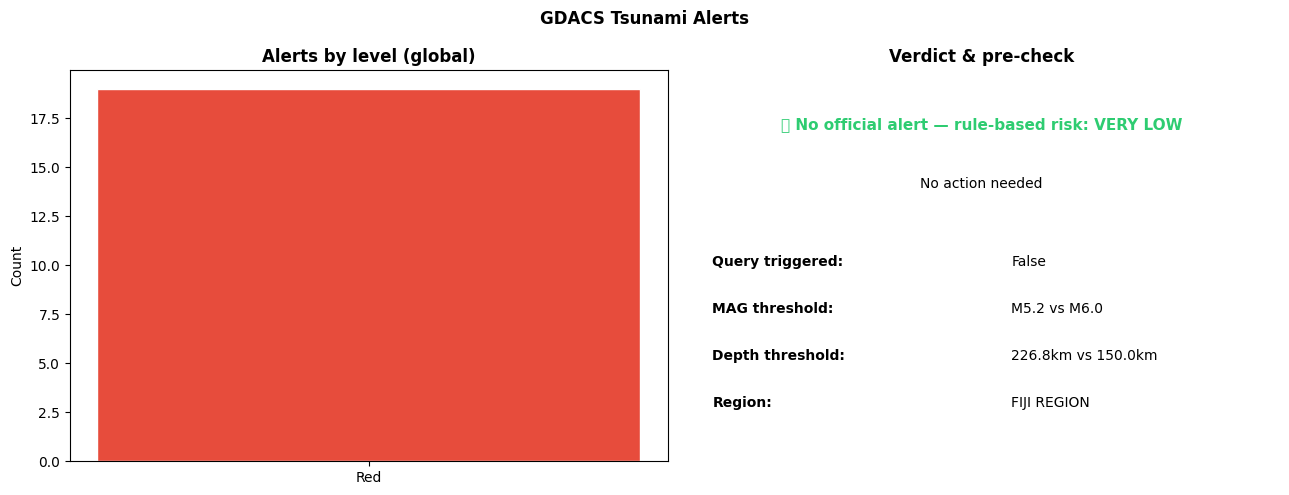

📊 Saved as nb7_gdacs_result.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("GDACS Tsunami Alerts", fontsize=12, fontweight='bold')

ax = axes[0]
if not df_all.empty and 'alert_level' in df_all.columns:
    level_counts = df_all['alert_level'].value_counts()
    LEVEL_COLORS = {'Red':'#e74c3c','Orange':'#e67e22','Green':'#2ecc71'}
    colors = [LEVEL_COLORS.get(l,'#aaa') for l in level_counts.index]
    ax.bar(level_counts.index, level_counts.values, color=colors, edgecolor='white')
    ax.set_ylabel("Count"); ax.set_title("Alerts by level (global)", fontweight='bold')
else:
    ax.text(0.5,0.5,"No active alerts",ha='center',va='center',transform=ax.transAxes,fontsize=14)
    ax.set_title("Active GDACS alerts", fontweight='bold')

ax = axes[1]; ax.axis('off')
verdict_color = '#e74c3c' if '⚠️' in verdict else '#2ecc71'
ax.text(0.5, 0.85, verdict, ha='center', fontsize=11, fontweight='bold',
        color=verdict_color, transform=ax.transAxes, wrap=True)
ax.text(0.5, 0.70, action, ha='center', fontsize=10, transform=ax.transAxes)
info = [("Query triggered",str(QUERY_OK)),("MAG threshold",f"M{MAG} vs M{TSUNAMI_MIN_MAG}"),
        ("Depth threshold",f"{DEPTH}km vs {TSUNAMI_MAX_DEPTH}km"),("Region",region)]
for i,(l,v) in enumerate(info):
    y=0.50-i*0.12
    ax.text(0.05,y,f"{l}:",fontweight='bold',fontsize=10,transform=ax.transAxes)
    ax.text(0.55,y,v,fontsize=10,transform=ax.transAxes)
ax.set_title("Verdict & pre-check", fontweight='bold')

plt.tight_layout()
plt.savefig("nb7_gdacs_result.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Saved as nb7_gdacs_result.png")